In [77]:
import pandas as pd
import numpy as np


In [78]:
df= pd.read_csv("/content/drive/MyDrive/DATASETS/powerplant_data.csv")

In [79]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [80]:
df.isnull().sum()

,0
AT,0
V,0
AP,0
RH,0
PE,0


In [81]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [82]:
X=df.drop('PE',axis=1)
y=df['PE']

In [83]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [84]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [85]:
import torch
import torch.nn as nn

In [86]:
X_train_tensor = torch.tensor(X_train_scaled,dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

In [87]:
X_test_tensor = torch.tensor(X_test_scaled,dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [88]:
from torch.utils.data import TensorDataset,DataLoader

In [89]:
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

In [90]:
train_loader  = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32)

In [91]:
class ANN(nn.Module):
    def __init__(self):
      super(ANN,self).__init__()

      self.model = nn.Sequential(
          #1st hidden layer
          nn.Linear(X_train.shape[1],6),
          nn.ReLU(),

          #2nd hidden layer
          nn.Linear(6,6),
          nn.ReLU(),

          #output layer
          nn.Linear(6,1),
      )

    def forward(self,x):
      return self.model(x)


In [92]:
import torch.optim as optim

model = ANN()

criterion = nn.MSELoss()
optimiser = optim.Adam(model.parameters())

In [93]:
train_loss = []
test_loss = []
epochs = 100
best_val_loss=float("inf")

for epoch in range(epochs):
  model.train()
  running_loss=0.0

  for xb,yb in train_loader:
    optimiser.zero_grad()
    outputs= model(xb)
    loss = criterion(outputs,yb)
    loss.backward()
    optimiser.step()

    running_loss+=loss.item()

  epoch_train_loss = running_loss/len(train_loader)
  train_loss.append(epoch_train_loss)

  model.eval()
  running_val_loss=0.0

  with torch.no_grad():
    for xb,yb in test_loader:
      outputs = model(xb)
      loss= criterion(outputs,yb)
      running_val_loss+=loss

  epoch_test_loss = running_val_loss/len(test_loader)
  test_loss.append(epoch_test_loss)


  print(f"for epoch {epoch+1}/{epochs} ==>training loss = {epoch_train_loss} & test loss ={epoch_test_loss}")

  if epoch_test_loss<best_val_loss:
    best_val_loss= epoch_test_loss
    torch.save(model.state_dict(),"best_model.pt")

for epoch 1/100 ==>training loss = 205734.23828125 & test loss =203448.78125
for epoch 2/100 ==>training loss = 195102.94622395834 & test loss =179879.015625
for epoch 3/100 ==>training loss = 150936.37526041668 & test loss =117633.4921875
for epoch 4/100 ==>training loss = 84485.20289713542 & test loss =56604.39453125
for epoch 5/100 ==>training loss = 39945.992854817705 & test loss =28961.02734375
for epoch 6/100 ==>training loss = 22999.360473632812 & test loss =19032.4609375
for epoch 7/100 ==>training loss = 16245.079231770833 & test loss =13958.16796875
for epoch 8/100 ==>training loss = 11968.136206054687 & test loss =10079.4853515625
for epoch 9/100 ==>training loss = 8471.825639343262 & test loss =7002.64208984375
for epoch 10/100 ==>training loss = 5776.265385945638 & test loss =4603.95458984375
for epoch 11/100 ==>training loss = 3677.6634251912433 & test loss =2903.578369140625
for epoch 12/100 ==>training loss = 2312.9250292460124 & test loss =1861.2037353515625
for epoch 

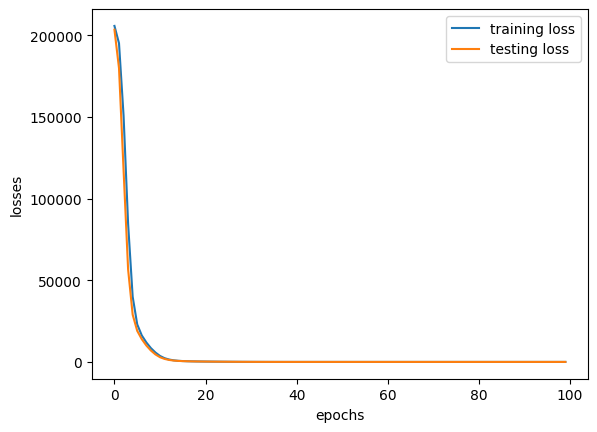

In [94]:
import matplotlib.pyplot as plt
loss_df= pd.DataFrame({
    "training loss":train_loss,
    "testing loss":test_loss
})

plt.plot(loss_df['training loss'],label = 'training loss')
plt.plot(loss_df['testing loss'],label='testing loss')

plt.xlabel('epochs')
plt.ylabel('losses')

plt.legend()

In [95]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [96]:
model.eval()
with torch.no_grad():
  train_pred = model(X_train_tensor)
  test_pred =model(X_test_tensor)

  train_mse_loss = criterion(train_pred,y_train_tensor)
  test_mse_loss=criterion(test_pred,y_test_tensor)

print("training  MSE loss", train_mse_loss.item())
print("testing MSE loss",test_mse_loss.item())

training  MSE loss 21.12885093688965
testing MSE loss 19.779430389404297
